# 02 Preprocessing and Feature Engineering

This notebook creates customer-level features for unsupervised learning.

**Input:** `outputs/transactions_cleaned.csv` (from Notebook 01)

**Output:**
- `outputs/customer_features.csv`
- `outputs/X_scaled.npy`
- `outputs/feature_columns.json`

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
BASE_DIR = Path.cwd()
INPUT_PATH = BASE_DIR / "outputs" / "transactions_cleaned.csv"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("INPUT_PATH:", INPUT_PATH)
print("Exists:", INPUT_PATH.exists())

INPUT_PATH: S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\transactions_cleaned.csv
Exists: True


In [3]:
df = pd.read_csv(INPUT_PATH)
print("Shape:", df.shape)
df.head()

Shape: (1000, 10)


,transaction_id,customer_id,customer_age,customer_gender,date,day_of_week,time_slot,total_amount,payment_method,items_json
0,TXN-2024-0000001,CUST1001,38,M,2024-01-07 19:17:00,Sun,Lunch,34,Cash,"[{""itemName"":""Lassi"",""quantity"":1,""price"":30,""..."
1,TXN-2024-0000002,CUST1002,36,F,2024-01-09 08:05:00,Tue,Lunch,142,Cash,"[{""itemName"":""Tea"",""quantity"":1,""price"":15,""ca..."
2,TXN-2024-0000003,CUST1003,42,M,2024-06-27 14:21:00,Thu,Lunch,105,Wallet,"[{""itemName"":""Veg Biryani"",""quantity"":1,""price..."
3,TXN-2024-0000004,CUST1004,21,F,2024-03-29 17:16:00,Fri,Dinner,85,UPI,"[{""itemName"":""Maggi"",""quantity"":1,""price"":40,""..."
4,TXN-2024-0000005,CUST1005,36,M,2024-06-29 09:02:00,Sat,Snacks,205,Wallet,"[{""itemName"":""Cold Coffee"",""quantity"":2,""price..."


In [4]:
# Ensure required fields exist
required_cols = ["customer_id", "total_amount"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
elif "transaction_ts" in df.columns:
    df["date"] = pd.to_datetime(df["transaction_ts"], errors="coerce")

if "day_of_week" not in df.columns and "date" in df.columns:
    df["day_of_week"] = df["date"].dt.day_name().str[:3]

if "time_slot" not in df.columns:
    df["time_slot"] = "Unknown"

df["total_amount"] = pd.to_numeric(df["total_amount"], errors="coerce").fillna(0)
df = df.dropna(subset=["customer_id"])

print("Post-standardization shape:", df.shape)
df.head()

Post-standardization shape: (1000, 10)


,transaction_id,customer_id,customer_age,customer_gender,date,day_of_week,time_slot,total_amount,payment_method,items_json
0,TXN-2024-0000001,CUST1001,38,M,2024-01-07 19:17:00,Sun,Lunch,34,Cash,"[{""itemName"":""Lassi"",""quantity"":1,""price"":30,""..."
1,TXN-2024-0000002,CUST1002,36,F,2024-01-09 08:05:00,Tue,Lunch,142,Cash,"[{""itemName"":""Tea"",""quantity"":1,""price"":15,""ca..."
2,TXN-2024-0000003,CUST1003,42,M,2024-06-27 14:21:00,Thu,Lunch,105,Wallet,"[{""itemName"":""Veg Biryani"",""quantity"":1,""price..."
3,TXN-2024-0000004,CUST1004,21,F,2024-03-29 17:16:00,Fri,Dinner,85,UPI,"[{""itemName"":""Maggi"",""quantity"":1,""price"":40,""..."
4,TXN-2024-0000005,CUST1005,36,M,2024-06-29 09:02:00,Sat,Snacks,205,Wallet,"[{""itemName"":""Cold Coffee"",""quantity"":2,""price..."


In [5]:
# Transaction-level helper flags
df["is_weekend"] = df["day_of_week"].isin(["Sat", "Sun"]).astype(int)
df["is_lunch"] = (df["time_slot"].astype(str).str.lower() == "lunch").astype(int)
df["is_snacks"] = (df["time_slot"].astype(str).str.lower() == "snacks").astype(int)
df["is_dinner"] = (df["time_slot"].astype(str).str.lower() == "dinner").astype(int)

df[["customer_id", "is_weekend", "is_lunch", "is_snacks", "is_dinner"]].head()

,customer_id,is_weekend,is_lunch,is_snacks,is_dinner
0,CUST1001,1,1,0,0
1,CUST1002,0,1,0,0
2,CUST1003,0,1,0,0
3,CUST1004,0,0,0,1
4,CUST1005,1,0,1,0


In [6]:
# Core customer features (RFM + behavioral ratios)
max_date = df["date"].max() if "date" in df.columns else pd.Timestamp.today()

customer = df.groupby("customer_id").agg(
    frequency_count=("customer_id", "size"),
    monetary_total=("total_amount", "sum"),
    avg_order_value=("total_amount", "mean"),
    weekend_ratio=("is_weekend", "mean"),
    lunch_ratio=("is_lunch", "mean"),
    snacks_ratio=("is_snacks", "mean"),
    dinner_ratio=("is_dinner", "mean"),
).reset_index()

if "date" in df.columns:
    last_tx = df.groupby("customer_id")["date"].max().reset_index(name="last_date")
    customer = customer.merge(last_tx, on="customer_id", how="left")
    customer["recency_days"] = (max_date - customer["last_date"]).dt.days
else:
    customer["recency_days"] = 0

customer = customer.fillna(0)
customer.head()

,customer_id,frequency_count,monetary_total,avg_order_value,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,last_date,recency_days
0,CUST1001,1,34,34.0,1.0,1.0,0.0,0.0,2024-01-07 19:17:00,173
1,CUST1002,1,142,142.0,0.0,1.0,0.0,0.0,2024-01-09 08:05:00,172
2,CUST1003,1,105,105.0,0.0,1.0,0.0,0.0,2024-06-27 14:21:00,2
3,CUST1004,1,85,85.0,0.0,0.0,0.0,1.0,2024-03-29 17:16:00,92
4,CUST1005,1,205,205.0,1.0,0.0,1.0,0.0,2024-06-29 09:02:00,0


In [7]:
# Optional: gender and age features if available
if "customer_age" in df.columns:
    age_stats = df.groupby("customer_id")["customer_age"].mean().reset_index(name="avg_customer_age")
    customer = customer.merge(age_stats, on="customer_id", how="left")

if "customer_gender" in df.columns:
    gender_mode = (
        df.groupby("customer_id")["customer_gender"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
        .reset_index(name="dominant_gender")
    )
    customer = customer.merge(gender_mode, on="customer_id", how="left")

customer.head()

,customer_id,frequency_count,monetary_total,avg_order_value,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,last_date,recency_days,avg_customer_age,dominant_gender
0,CUST1001,1,34,34.0,1.0,1.0,0.0,0.0,2024-01-07 19:17:00,173,38.0,M
1,CUST1002,1,142,142.0,0.0,1.0,0.0,0.0,2024-01-09 08:05:00,172,36.0,F
2,CUST1003,1,105,105.0,0.0,1.0,0.0,0.0,2024-06-27 14:21:00,2,42.0,M
3,CUST1004,1,85,85.0,0.0,0.0,0.0,1.0,2024-03-29 17:16:00,92,21.0,F
4,CUST1005,1,205,205.0,1.0,0.0,1.0,0.0,2024-06-29 09:02:00,0,36.0,M


In [8]:
# Select numeric model features
candidate_cols = [
    "recency_days",
    "frequency_count",
    "monetary_total",
    "avg_order_value",
    "weekend_ratio",
    "lunch_ratio",
    "snacks_ratio",
    "dinner_ratio",
    "avg_customer_age",
]

feature_cols = [c for c in candidate_cols if c in customer.columns]
X = customer[feature_cols].copy().fillna(0)

print("Feature columns:", feature_cols)
print("X shape:", X.shape)
X.head()

Feature columns: ['recency_days', 'frequency_count', 'monetary_total', 'avg_order_value', 'weekend_ratio', 'lunch_ratio', 'snacks_ratio', 'dinner_ratio', 'avg_customer_age']
X shape: (1000, 9)


,recency_days,frequency_count,monetary_total,avg_order_value,weekend_ratio,lunch_ratio,snacks_ratio,dinner_ratio,avg_customer_age
0,173,1,34,34.0,1.0,1.0,0.0,0.0,38.0
1,172,1,142,142.0,0.0,1.0,0.0,0.0,36.0
2,2,1,105,105.0,0.0,1.0,0.0,0.0,42.0
3,92,1,85,85.0,0.0,0.0,0.0,1.0,21.0
4,0,1,205,205.0,1.0,0.0,1.0,0.0,36.0


In [9]:
# Scale features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled matrix shape:", X_scaled.shape)
print("Means (approx):", np.round(X_scaled.mean(axis=0), 4))
print("Std (approx):", np.round(X_scaled.std(axis=0), 4))

Scaled matrix shape: (1000, 9)
Means (approx): [-0.  0.  0.  0. -0.  0. -0.  0. -0.]
Std (approx): [1. 0. 1. 1. 1. 1. 1. 1. 1.]


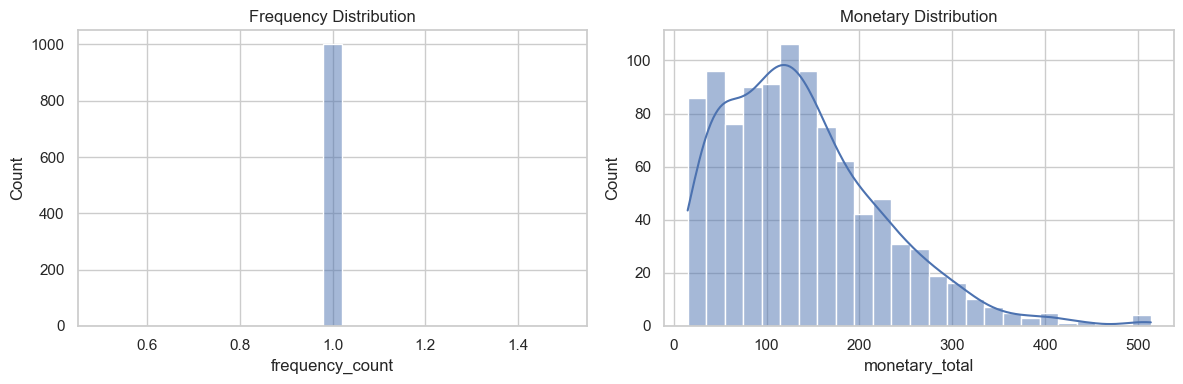

In [10]:
# Quick sanity distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(customer["frequency_count"], bins=25, kde=True, ax=axes[0])
axes[0].set_title("Frequency Distribution")

sns.histplot(customer["monetary_total"], bins=25, kde=True, ax=axes[1])
axes[1].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [11]:
# Save outputs for next notebooks
customer_out = OUTPUT_DIR / "customer_features.csv"
np_out = OUTPUT_DIR / "X_scaled.npy"
feature_out = OUTPUT_DIR / "feature_columns.json"

customer.to_csv(customer_out, index=False)
np.save(np_out, X_scaled)
feature_out.write_text(json.dumps(feature_cols, indent=2), encoding="utf-8")

print("Saved:")
print("-", customer_out)
print("-", np_out)
print("-", feature_out)

Saved:
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\customer_features.csv
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\X_scaled.npy
- S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\feature_columns.json


## Next Notebook

Continue with `03_clustering_kmeans_dbscan_gmm_hierarchical.ipynb` to train and compare clustering models using `X_scaled.npy` and `customer_features.csv`.